In [1]:
#importing libraries

import os
import numpy as np
import torch
import time
import torch.utils.data
from torch.utils.data.dataset import Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random
import cv2
import glob
from PIL import Image
import ntpath
import os
from tqdm import tqdm
from tqdm import trange
%matplotlib inline

In [32]:
def START_seed():
    seed = 9
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

lr = 1e-4
epochs=5
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_batch_size = 64
test_batch_size = 256
ACLASSES = ('buildings', 'forest', 'glacier', 'mountain', 'sea', 'street')

### DATASET CLASS

In [33]:
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
from glob import glob
import os


In [34]:
data_folder_train = r"C:\dev\MBZ\CV701\Lab_09\data\NIdataset_v2\seg_train"
data_folder_test = r"C:\dev\MBZ\CV701\Lab_09\data\NIdataset_v2\seg_test"
data_folder_val = r"C:\dev\MBZ\CV701\Lab_09\data\NIdataset_v2\seg_val"

class CustomDataset(Dataset):
    def __init__(self, data_folder, transform=None):
        #initialisation
        self.transform = transform
        self.data_folder = data_folder
        self.class_to_idx = {'buildings':0,'forest':1,'glacier':2,'mountain':3,'sea':4,'street':5} #optional can change acc to your code
        self.samples = self.make_dataset()
        
    def make_dataset(self):
        #can use this (Optional)
        samples = []
        for key, value in self.class_to_idx.items():
            for i in glob(os.path.join(self.data_folder, key, '*.jpg')):
                samples.append((i, value))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        #get item code
        image_path, target = self.samples[index]
        sample = Image.open(image_path)
        if self.transform is not None:
            sample = self.transform(sample)
        else:
            sample = transforms.Compose([
                transforms.Resize((150,150)),
                transforms.ToTensor()
            ])
        target=torch.tensor(target).long()
        return sample, target

### INITIALISE THE DATASET and THE DATALOADERS 

In [35]:

START_seed()
# Define your transformations (hint:use augmentations)
transform = transforms.Compose([
    transforms.Resize((150,150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(0, shear=10, scale=(0.8,1.2)),
    transforms.ToTensor()
])
# dataset initialisation
train_ds = CustomDataset(data_folder_train, transform)
val_ds = CustomDataset(data_folder_val, transform)
test_ds = CustomDataset(data_folder_test, transform)

#loader initialisation
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=train_batch_size, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=test_batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=test_batch_size, shuffle=False)


## Visualizing Data

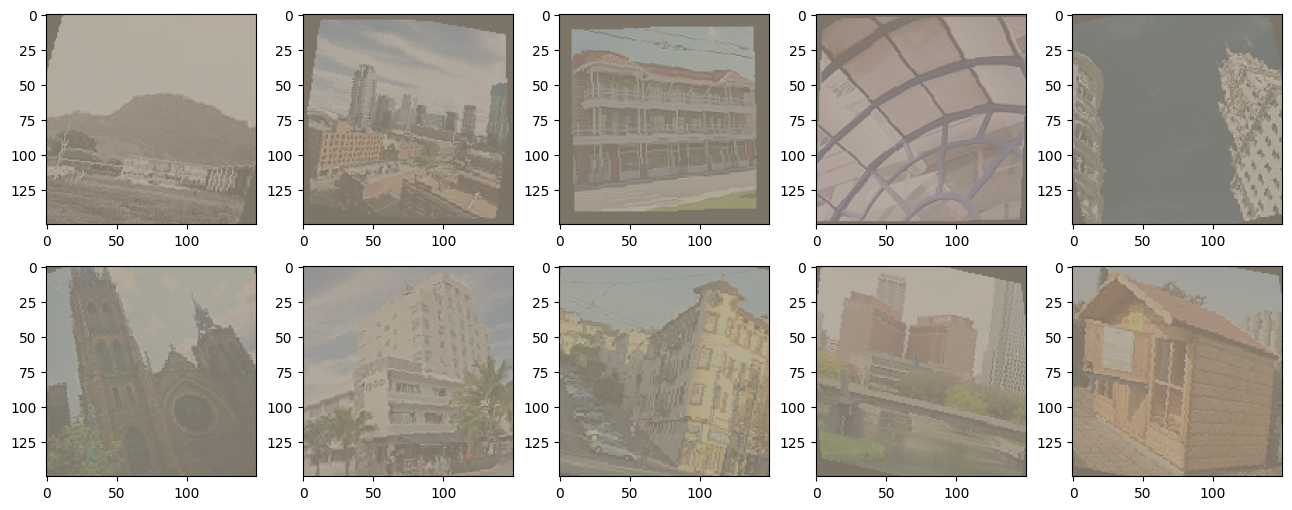

In [36]:
# show some images
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    image, _ = train_loader.dataset.__getitem__(i)
    image= image.permute(1,2,0).numpy()
    image = (image*std)+mean
    plt.imshow(image)

In [37]:
for image, target in train_loader:
    print(image.shape, target.shape)
    break

torch.Size([64, 3, 150, 150]) torch.Size([64])


### Initialise the model, optimizers, schedulers 

In [38]:
START_seed()
import torchvision.models as models

#models you can use Resnet-18, VGG-16, Resnet-50. Also dont forget to change the last layer output classes
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 6)
print(model)

pytorch_total_params = sum(p.numel() for p in  model.parameters())
print('Number of parameters: {0}'.format(pytorch_total_params))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

c:\software\python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\software\python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [39]:
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr) 


### Training and evaluation loop

In [41]:
# ## Creating training loop
def train(model):
    for batch_idx, (image, target) in tqdm(enumerate(train_loader)):
        train_loss = 0
        correct = 0
        total = 0
        image, target = image.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)
    #write your code
        print(' train loss: {:.4f} accuracy: {:.4f}'.format(train_loss/(batch_idx+1), 100.*correct/total))

In [42]:
def validate(model):   
    #write your code
    with torch.no_grad():
        best_accuracy = 0        
        for batch_idx, (image, target) in tqdm(enumerate(val_loader)):
            correct = 0
            total = 0
            val_loss = 0
            image, target = image.to(device), target.to(device)
            output = model(image)
            loss = criterion(output, target)
            val_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
            val_accuracy = 100.*correct/total
            print(' val loss: {:.4f} accuracy: {:.4f} best_accuracy: {:.4f}'.format(val_loss/(batch_idx+1), 100.*correct/total, best_accuracy))
            if val_accuracy > best_accuracy: #OPTIONAL CAN FILL FOR SAVING THE BEST MODEL or else remove it
                best_accuracy = val_accuracy
                torch.save(model.state_dict(), 'best_model.pth')

In [43]:
model.to(device)
start = time.time()
for epoch in range(0, epochs):
    print("epoch number: {0}".format(epoch))
    train( model)
    validate(model)
end = time.time()
Total_time=end-start
print('Total training and inference time is: {0}'.format(Total_time))

epoch number: 0


3it [00:00,  8.57it/s]

 train loss: 1.9399 accuracy: 15.6250
 train loss: 1.0047 accuracy: 12.5000
 train loss: 0.6479 accuracy: 10.9375


5it [00:00, 10.39it/s]

 train loss: 0.4861 accuracy: 17.1875
 train loss: 0.4059 accuracy: 17.1875
 train loss: 0.3264 accuracy: 15.6250


...

 val loss: 0.2176 accuracy: 7.0312 best_accuracy: 30.4688


10it [00:03,  3.25it/s]

 val loss: 0.1734 accuracy: 24.2188 best_accuracy: 30.4688


11it [00:03,  3.15it/s]

 val loss: 0.1630 accuracy: 21.6000 best_accuracy: 30.4688
Total training and inference time is: 90.59728336334229


### Test the model 

In [44]:
def test_best_model(model, test_loader, criterion, best_model_path):
    # Load the best model
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    with tqdm(test_loader, unit="batch") as tepoch:
        for batch_idx, (data, target) in enumerate(tepoch):
            data, target = data.to(device), target.to(device)

            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item()

            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        accuracy = 100. * correct / total
        print('Test loss: {:.4f} Accuracy: {:.2f}%'.format(test_loss/(batch_idx+1), accuracy))

# Usage example:
# Assuming you have a model, test_loader, and best_model_path defined

best_model_path = 'best_model.pth'  # Replace with the actual path and filename of the best model

test_best_model(model, test_loader, nn.CrossEntropyLoss(), best_model_path)


C:\Users\maxim.popov\AppData\Local\Temp\ipykernel_25112\2605423959.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))
100

Test loss: 1.5564 Accuracy: 39.17%
